In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

model_names = ['logistic_regression', 'random_forest', 'xgboost']
models = {}
for name in model_names:
    with open(f'../models/{name}.pkl', 'rb') as f:
        models[name] = pickle.load(f)

print(f"Test set: {X_test.shape}")
print(f"Models loaded: {list(models.keys())}")

Test set: (508010, 41)
Models loaded: ['logistic_regression', 'random_forest', 'xgboost']


In [3]:
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)
    print(f"{name} done")

logistic_regression done
random_forest done
xgboost done


In [4]:
results = []
for name, y_pred in predictions.items():
    results.append({
        "Model": name.replace("_", " ").title(),
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "F1 Score":  round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df

,Model,Accuracy,F1 Score,Precision,Recall
1,Random Forest,0.9959,0.9838,0.9849,0.9827
2,Xgboost,0.9949,0.9796,0.9823,0.9770
0,Logistic Regression,0.9881,0.9539,0.9391,0.9692


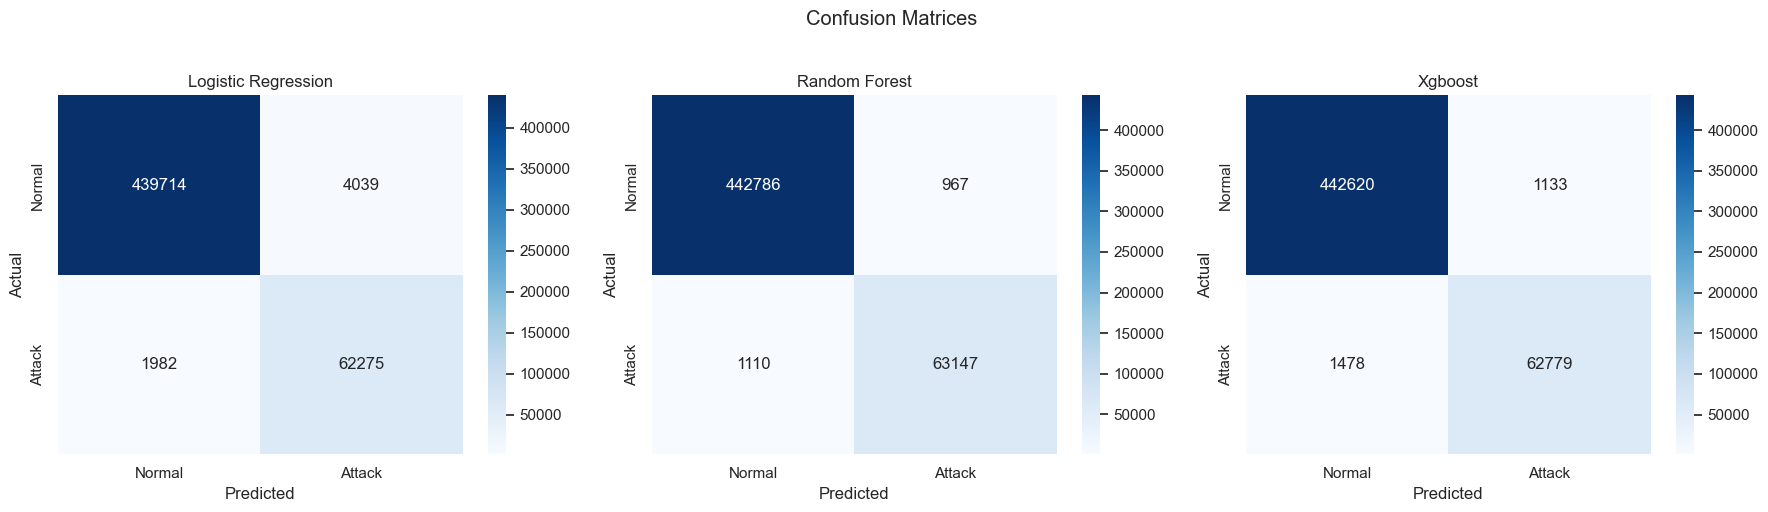

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    ax.set_title(name.replace("_", " ").title())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

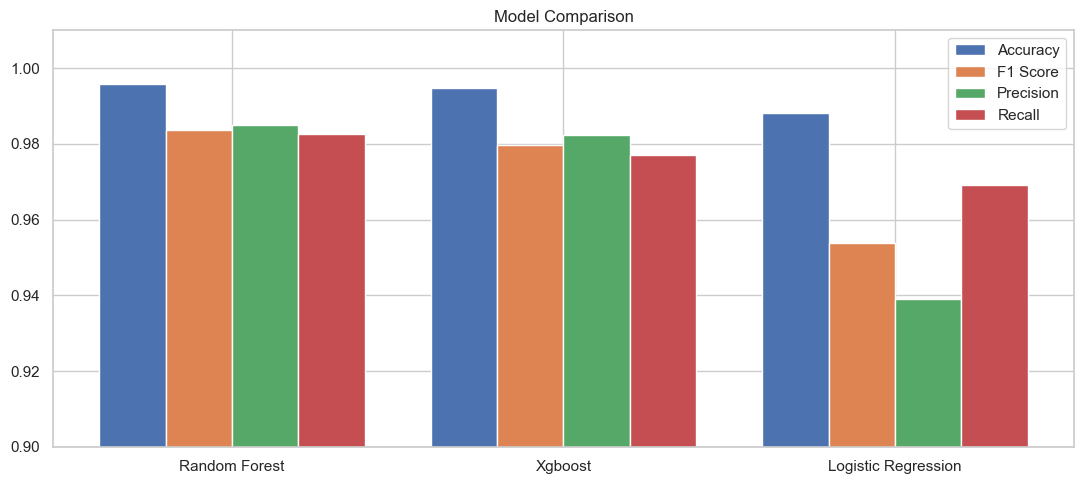

In [6]:
metrics = ["Accuracy", "F1 Score", "Precision", "Recall"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0.9, 1.01)
ax.set_title("Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\dcphi\AppData\Local\Temp\ipykernel_30352\2443133139.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')


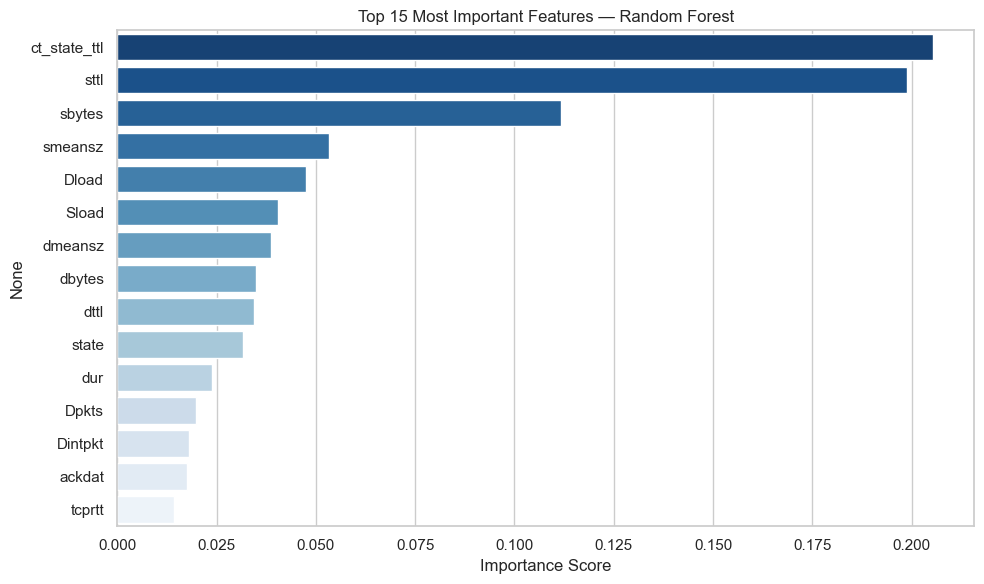

In [7]:
importances = models['random_forest'].feature_importances_
feat_imp = pd.Series(importances, index=X_test.columns)
top_features = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Conclusions

- All three models performed exceptionally well on this dataset
- **Random Forest** achieved the best F1 score of 98.38%, correctly identifying 98.27% of attacks
- **XGBoost** was nearly identical at 97.96% F1 and trained in under 9 seconds — the best speed/accuracy tradeoff
- **Logistic Regression** still reached 95.39% F1 as a simple baseline, suggesting strong linear patterns exist in the data
- The feature importance chart reveals which network traffic characteristics are most predictive of attacks
- In a real deployment, XGBoost would likely be preferred due to its speed advantage with minimal accuracy tradeoff